<a href="https://colab.research.google.com/github/marcelagrg/challenge-telecomx/blob/main/Challenge_TelecomX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📌 Extracão

In [ ]:
import pandas as pd
import requests

In [ ]:
url = 'https://raw.githubusercontent.com/alura-cursos/challenge2-data-science/refs/heads/main/TelecomX_Data.json'
response = requests.get(url)
data = response.json()
df = pd.DataFrame(data)

In [ ]:
df = pd.json_normalize(data)

In [ ]:
df

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


# 🔧 Transformação

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

###1. Transformação da coluna "account.Charges.Total" em Float

In [ ]:
df.loc[:, 'account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

### 2. Verificação dos valores únicos

In [ ]:
for col in df.columns:
    print(col, df[col].unique())

customerID ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
Churn ['No' 'Yes' '']
customer.gender ['Female' 'Male']
customer.SeniorCitizen [0 1]
customer.Partner ['Yes' 'No']
customer.Dependents ['Yes' 'No']
customer.tenure [ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 51 31 36 17 18 38 42
  0]
phone.PhoneService ['Yes' 'No']
phone.MultipleLines ['No' 'Yes' 'No phone service']
internet.InternetService ['DSL' 'Fiber optic' 'No']
internet.OnlineSecurity ['No' 'Yes' 'No internet service']
internet.OnlineBackup ['Yes' 'No' 'No internet service']
internet.DeviceProtection ['No' 'Yes' 'No internet service']
internet.TechSupport ['Yes' 'No' 'No internet service']
internet.StreamingTV ['Yes' 'No' 'No internet service']
internet.StreamingMovies ['No' 'Yes' 'No internet service']
account.Contract ['One year' 'M

###3. Verificação dos valores duplicados




In [ ]:
print ("Valores duplicados: ", df.duplicated().sum())

Valores duplicados:  0


### 4. Transformação dos valores vazios em nulos

In [ ]:
import numpy as np
df = df.replace(r'^\s*$', np.nan, regex=True)

/tmp/ipykernel_360/4033771716.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(r'^\s*$', np.nan, regex=True)


### 5. Verificação dos valores nulos

In [ ]:
df.isnull().sum()

,0
customerID,0
Churn,224
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


###6. Remoção dos valores nulos

São selecionadas apenas as colunas que possuem valores nulos: 'Churn' e 'account.Charges.Total'

In [ ]:
df = df.dropna(subset=['Churn', 'account.Charges.Total'])
df.isnull().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


#*Opcional*

### *1. Criação da coluna Contas diárias*

In [ ]:
df['contas_diarias'] = df['account.Charges.Monthly'] / 30
df['contas_diarias']

,contas_diarias
0,2.186667
1,1.996667
2,2.463333
3,3.266667
4,2.796667
...,...
7262,1.838333
7263,2.836667
7264,1.676667
7265,2.261667


###*2. Padronização e tradução dos títulos das colunas*

In [ ]:
colunas = {
    'customerID': 'id_cliente',
    'Churn': 'cancelamento',
    'customer.gender': 'genero',
    'customer.SeniorCitizen': 'idoso',
    'customer.Partner': 'possui_parceiro',
    'customer.Dependents': 'possui_dependentes',
    'customer.tenure': 'meses_de_contrato',
    'phone.PhoneService': 'servico_telefone',
    'phone.MultipleLines': 'multiplas_linhas',
    'internet.InternetService': 'tipo_internet',
    'internet.OnlineSecurity': 'seguranca_online',
    'internet.OnlineBackup': 'backup_online',
    'internet.DeviceProtection': 'protecao_dispositivo',
    'internet.TechSupport': 'suporte_tecnico',
    'internet.StreamingTV': 'streaming_tv',
    'internet.StreamingMovies': 'streaming_filmes',
    'account.Contract': 'tipo_contrato',
    'account.PaperlessBilling': 'fatura_digital',
    'account.PaymentMethod': 'metodo_pagamento',
    'account.Charges.Monthly': 'valor_mensal',
    'account.Charges.Total': 'total_gasto'
}
df = df.rename(columns = colunas)
df

,id_cliente,cancelamento,genero,idoso,possui_parceiro,possui_dependentes,meses_de_contrato,servico_telefone,multiplas_linhas,tipo_internet,...,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,valor_mensal,total_gasto,contas_diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,Yes,No,No,One year,No,Mailed check,55.15,742.90,1.838333
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70,2.836667
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75,1.676667
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65,2.261667


### *3. Padronização da coluna idoso*


In [ ]:
df['idoso'] = df['idoso'].replace({1: 'Sim', 0: 'Não'})
df['idoso']

,idoso
0,Não
1,Não
2,Não
3,Sim
4,Sim
...,...
7262,Não
7263,Não
7264,Não
7265,Não


###*4. Tradução das células para português*

In [ ]:
colunas_traduzidas = ['cancelamento','possui_parceiro','possui_dependentes', 'servico_telefone', 'fatura_digital']
mapping = {'No': 'Não', 'Yes': 'Sim'}
for col in colunas_traduzidas:
    df[col] = df[col].replace(mapping)

In [ ]:
colunas_traduzidas2 = ['seguranca_online', 'backup_online', 'protecao_dispositivo', 'suporte_tecnico', 'streaming_tv', 'streaming_filmes']
mapping = {'No': 'Não', 'Yes': 'Sim', 'No internet service': 'Sem serviço de internet'}
for col in colunas_traduzidas2:
    df[col] = df[col].replace(mapping)

In [ ]:
df['genero'] = df['genero'].replace({'Male' : 'Masculino', 'Female': 'Feminino'})
df['multiplas_linhas'] = df['multiplas_linhas'].replace({'Yes' : 'Sim', 'No' : 'Não', 'No phone service' : 'Sem serviço telefônico'})
df['tipo_internet'] = df['tipo_internet'].replace({'Fiber optic' : 'Fibra ótica', 'No' : 'Não'})
df['tipo_contrato'] = df['tipo_contrato'].replace({'One year': 'Anual', 'Month-to-month': 'Mensal', 'Two year': 'Bienal'})

In [ ]:
df['metodo_pagamento'] = df['metodo_pagamento'].replace({
    'Mailed check': 'Cheque físico ',
    'Electronic check': 'Cheque eletrônico',
    'Credit card (automatic)': 'Cartão de crédito (automático)',
    'Bank transfer (automatic)': 'Transferência bancária (automática)'
})

# 📊 Carregamento

### 1. Análise descritiva

In [ ]:
df.describe()

,meses_de_contrato,valor_mensal,total_gasto,contas_diarias
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441,2.159940
std,24.545260,30.085974,2266.771362,1.002866
min,1.000000,18.250000,18.800000,0.608333
25%,9.000000,35.587500,401.450000,1.186250
50%,29.000000,70.350000,1397.475000,2.345000
75%,55.000000,89.862500,3794.737500,2.995417
max,72.000000,118.750000,8684.800000,3.958333



- count: contagem de células não nulas
- mean: média
- std: desvio padrão
- min: menor valor encontrado
- 25%: primeiro quartil
- 50%: segundo quartil, mediana
- 75% terceiro quartil
- max: valor máximo encontrado

*Análise descritiva apenas dos clientes que cancelaram o contrato*

In [ ]:
df[df['cancelamento'] == 'Sim'].describe()

,meses_de_contrato,valor_mensal,total_gasto,contas_diarias
count,1869.000000,1869.000000,1869.000000,1869.000000
mean,17.979133,74.441332,1531.796094,2.481378
std,19.531123,24.666053,1890.822994,0.822202
min,1.000000,18.850000,18.850000,0.628333
25%,2.000000,56.150000,134.500000,1.871667
50%,10.000000,79.650000,703.550000,2.655000
75%,29.000000,94.200000,2331.300000,3.140000
max,72.000000,118.350000,8684.800000,3.945000


### 2. Distribuição da evasão de clientes



In [ ]:
df[df['cancelamento'] == 'Sim']

,id_cliente,cancelamento,genero,idoso,possui_parceiro,possui_dependentes,meses_de_contrato,servico_telefone,multiplas_linhas,tipo_internet,...,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,valor_mensal,total_gasto,contas_diarias
2,0004-TLHLJ,Sim,Masculino,Não,Não,Não,4,Sim,Não,Fibra ótica,...,Sim,Não,Não,Não,Mensal,Sim,Cheque eletrônico,73.90,280.85,2.463333
3,0011-IGKFF,Sim,Masculino,Sim,Sim,Não,13,Sim,Não,Fibra ótica,...,Sim,Não,Sim,Sim,Mensal,Sim,Cheque eletrônico,98.00,1237.85,3.266667
4,0013-EXCHZ,Sim,Feminino,Sim,Sim,Não,3,Sim,Não,Fibra ótica,...,Não,Sim,Sim,Não,Mensal,Sim,Cheque físico,83.90,267.40,2.796667
18,0022-TCJCI,Sim,Masculino,Sim,Não,Não,45,Sim,Não,DSL,...,Sim,Não,Não,Sim,Anual,Não,Cartão de crédito (automático),62.70,2791.50,2.090000
19,0023-HGHWL,Sim,Masculino,Sim,Não,Não,1,Não,Sem serviço telefônico,DSL,...,Não,Não,Não,Não,Mensal,Sim,Cheque eletrônico,25.10,25.10,0.836667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7243,9961-JBNMK,Sim,Masculino,Sim,Não,Não,21,Sim,Não,Fibra ótica,...,Sim,Não,Sim,Sim,Mensal,Sim,Transferência bancária (automática),96.80,2030.30,3.226667
7246,9965-YOKZB,Sim,Masculino,Sim,Não,Não,9,Sim,Sim,Fibra ótica,...,Não,Não,Não,Sim,Mensal,Sim,Cheque eletrônico,83.85,790.15,2.795000
7260,9985-MWVIX,Sim,Feminino,Não,Não,Não,1,Sim,Não,Fibra ótica,...,Não,Não,Não,Não,Mensal,Sim,Cheque físico,70.15,70.15,2.338333
7261,9986-BONCE,Sim,Feminino,Não,Não,Não,4,Sim,Não,Não,...,Sem serviço de internet,Sem serviço de internet,Sem serviço de internet,Sem serviço de internet,Mensal,Não,Transferência bancária (automática),20.95,85.50,0.698333


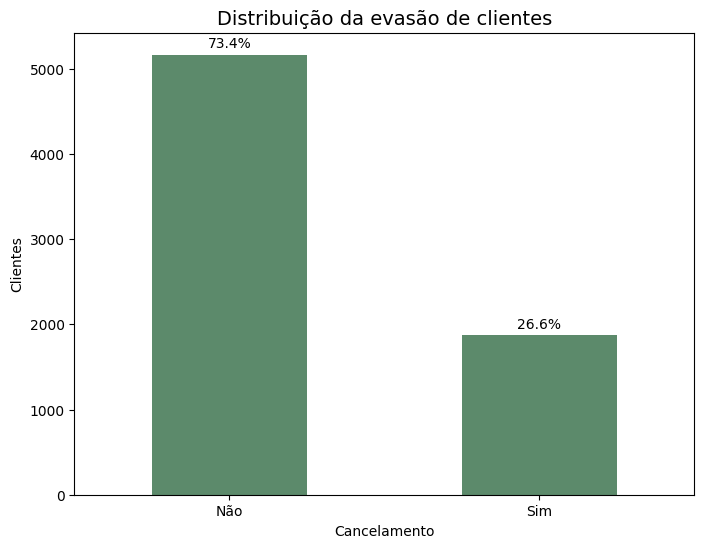

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

contagem_cancelamentos = df['cancelamento'].value_counts()
porcentagem_cancelamento = contagem_cancelamentos / len(df) * 100

ax = contagem_cancelamentos.plot(kind='bar', color='#5c8a6b')
plt.title('Distribuição da evasão de clientes', fontsize=14)
plt.xlabel('Cancelamento')
plt.ylabel('Clientes')
plt.xticks(rotation=0)

for i, percentage in enumerate(porcentagem_cancelamento):
    ax.text(i, contagem_cancelamentos.iloc[i] + 50, f'{percentage:.1f}%', ha='center', va='bottom')

plt.show()

### 3. Distribuição da evasão de clientes por variáveis categóricas

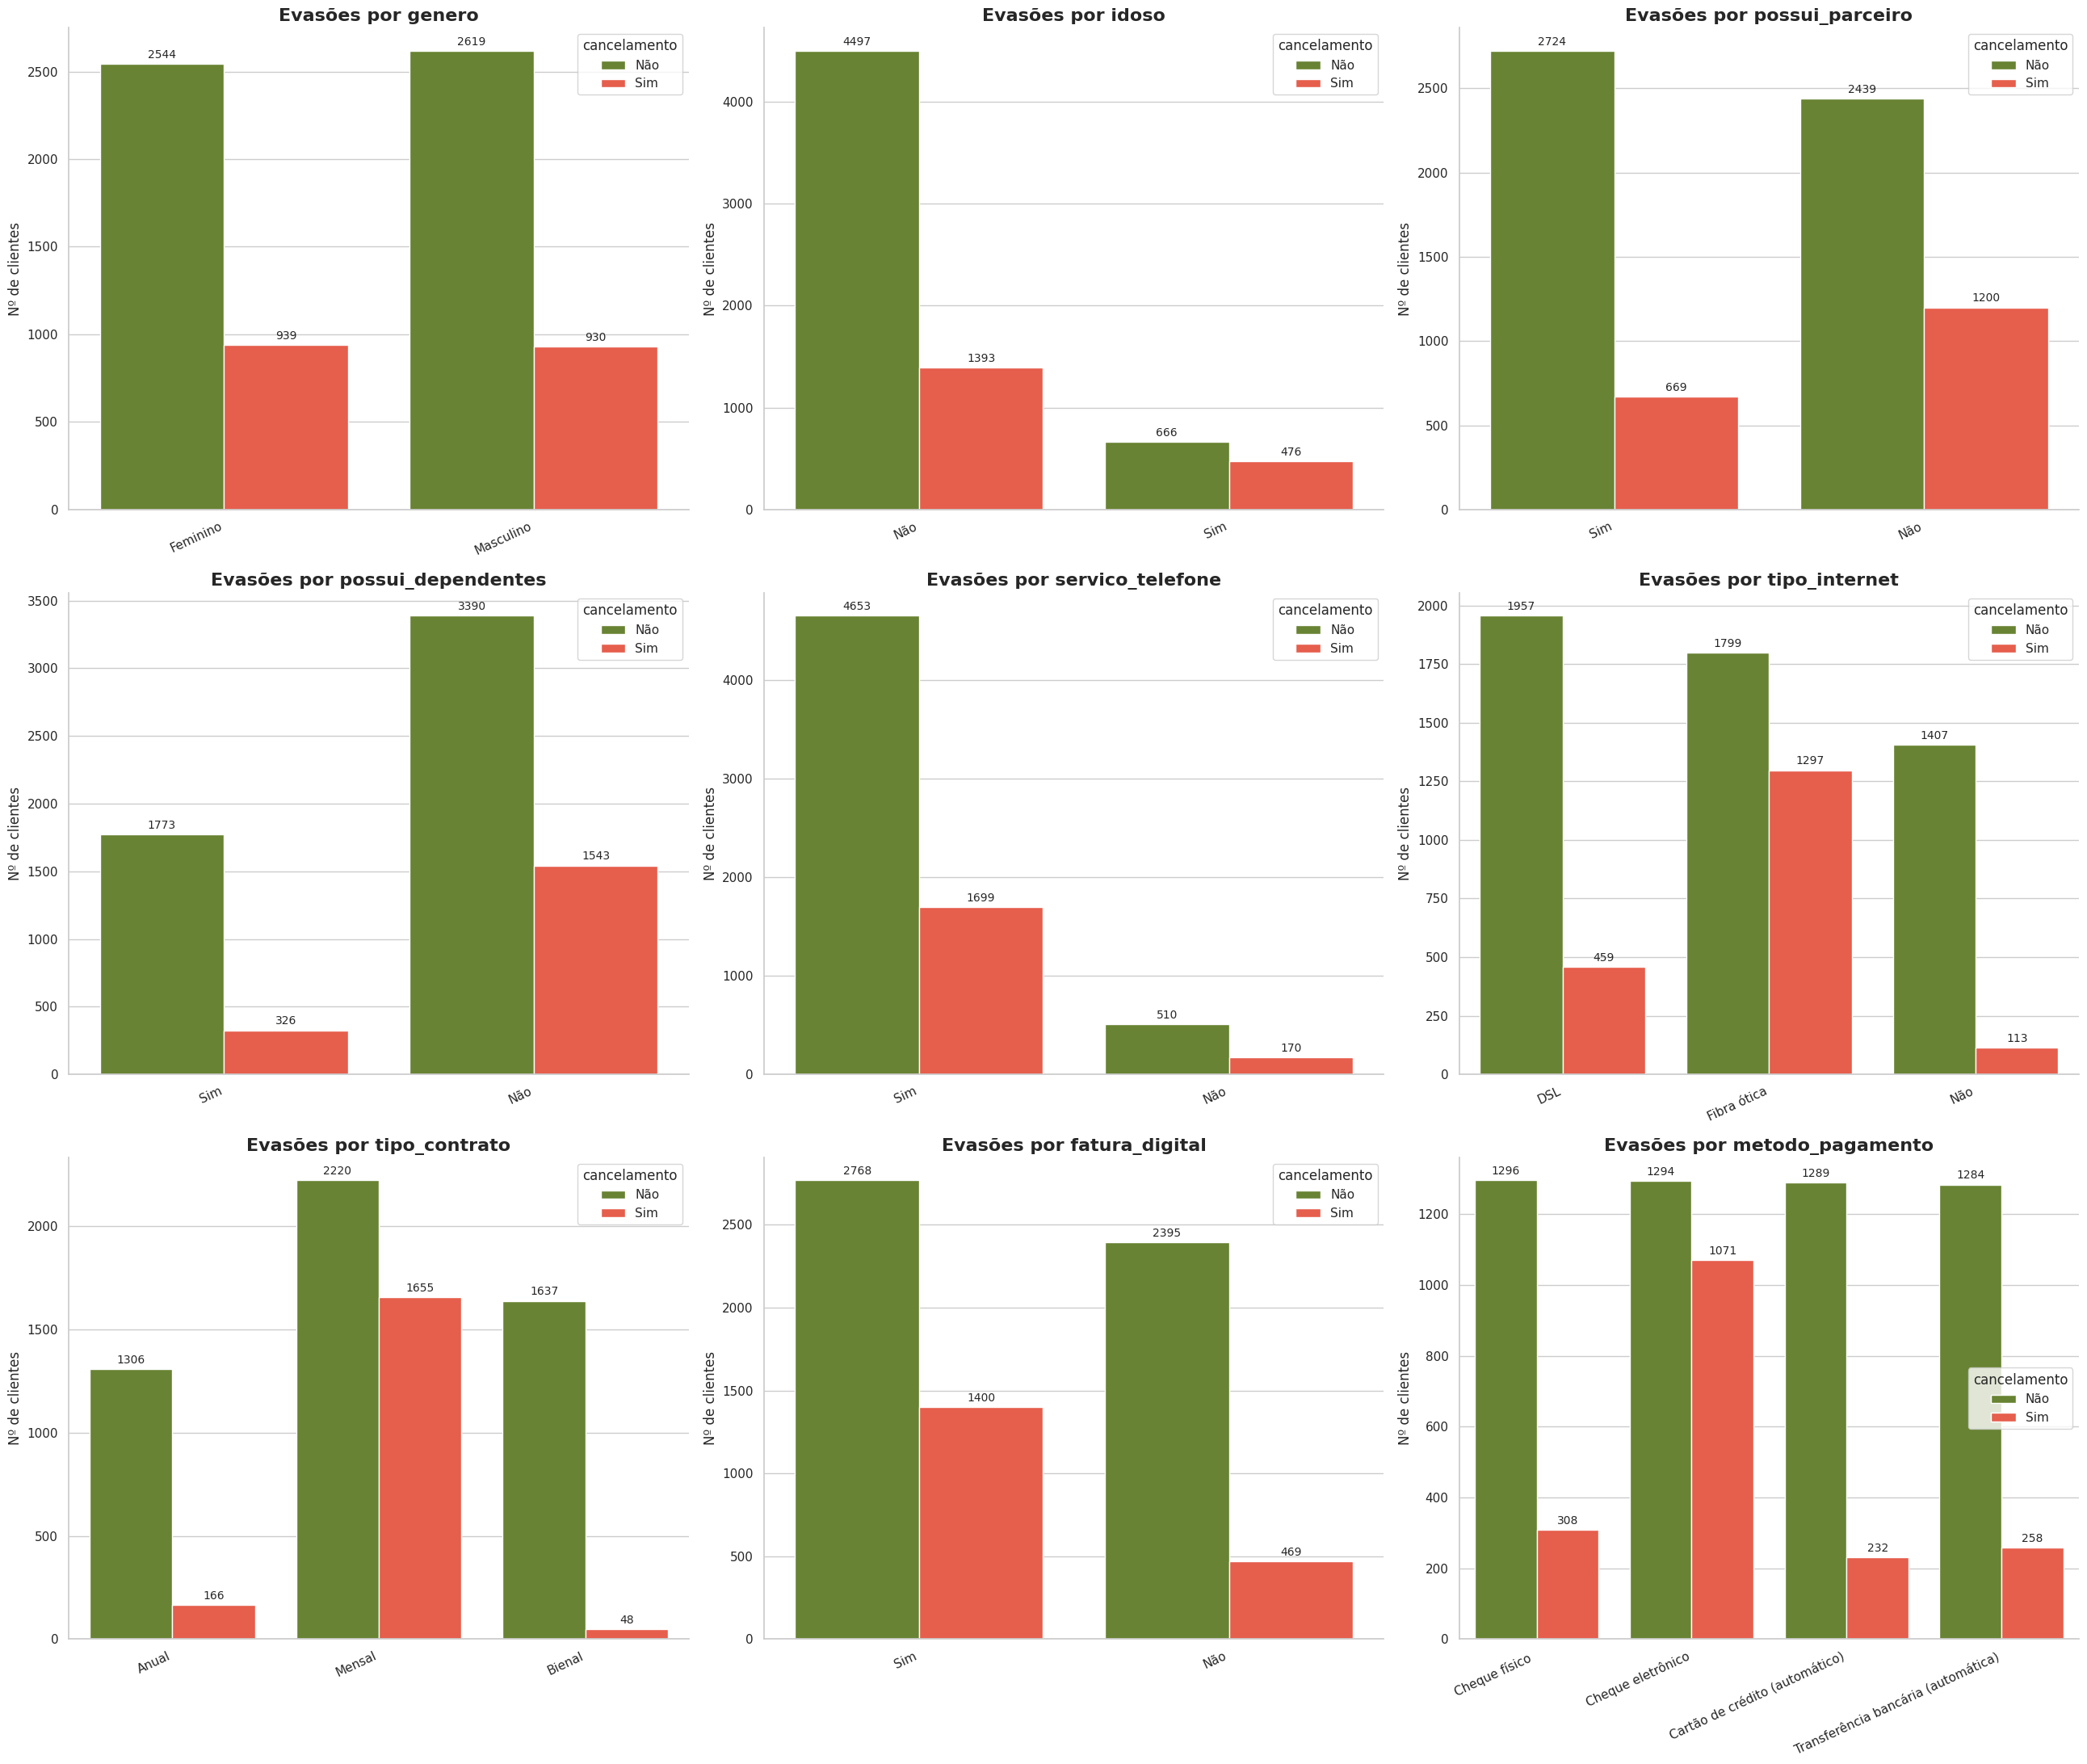

In [ ]:
import seaborn as sns

variaveis_categoricas = ['genero', 'idoso', 'possui_parceiro',
       'possui_dependentes', 'servico_telefone', 'tipo_internet',
       'tipo_contrato', 'fatura_digital', 'metodo_pagamento']

lista_variaveis_categoricas = list(enumerate(variaveis_categoricas))

sns.set_theme(style="whitegrid")

plt.figure(figsize=(26, 22))

for i, var in enumerate(variaveis_categoricas):

    plt.subplot(3, 3, i + 1)

    ax = sns.countplot(data=df, x=var, hue='cancelamento', palette=['#6c9026', '#ff4b33'])

    ax.set_title(f'Evasões por {var}', fontsize=16, fontweight='bold')
    ax.set_ylabel('Nº de clientes', fontsize=12)
    ax.set_xlabel('')

    plt.xticks(rotation=25, ha='right')

    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(
                f'{int(height)}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center',
                va='bottom',
                fontsize=10,
                xytext=(0, 3),
                textcoords='offset points'
            )

    sns.despine()

plt.tight_layout()
plt.show()

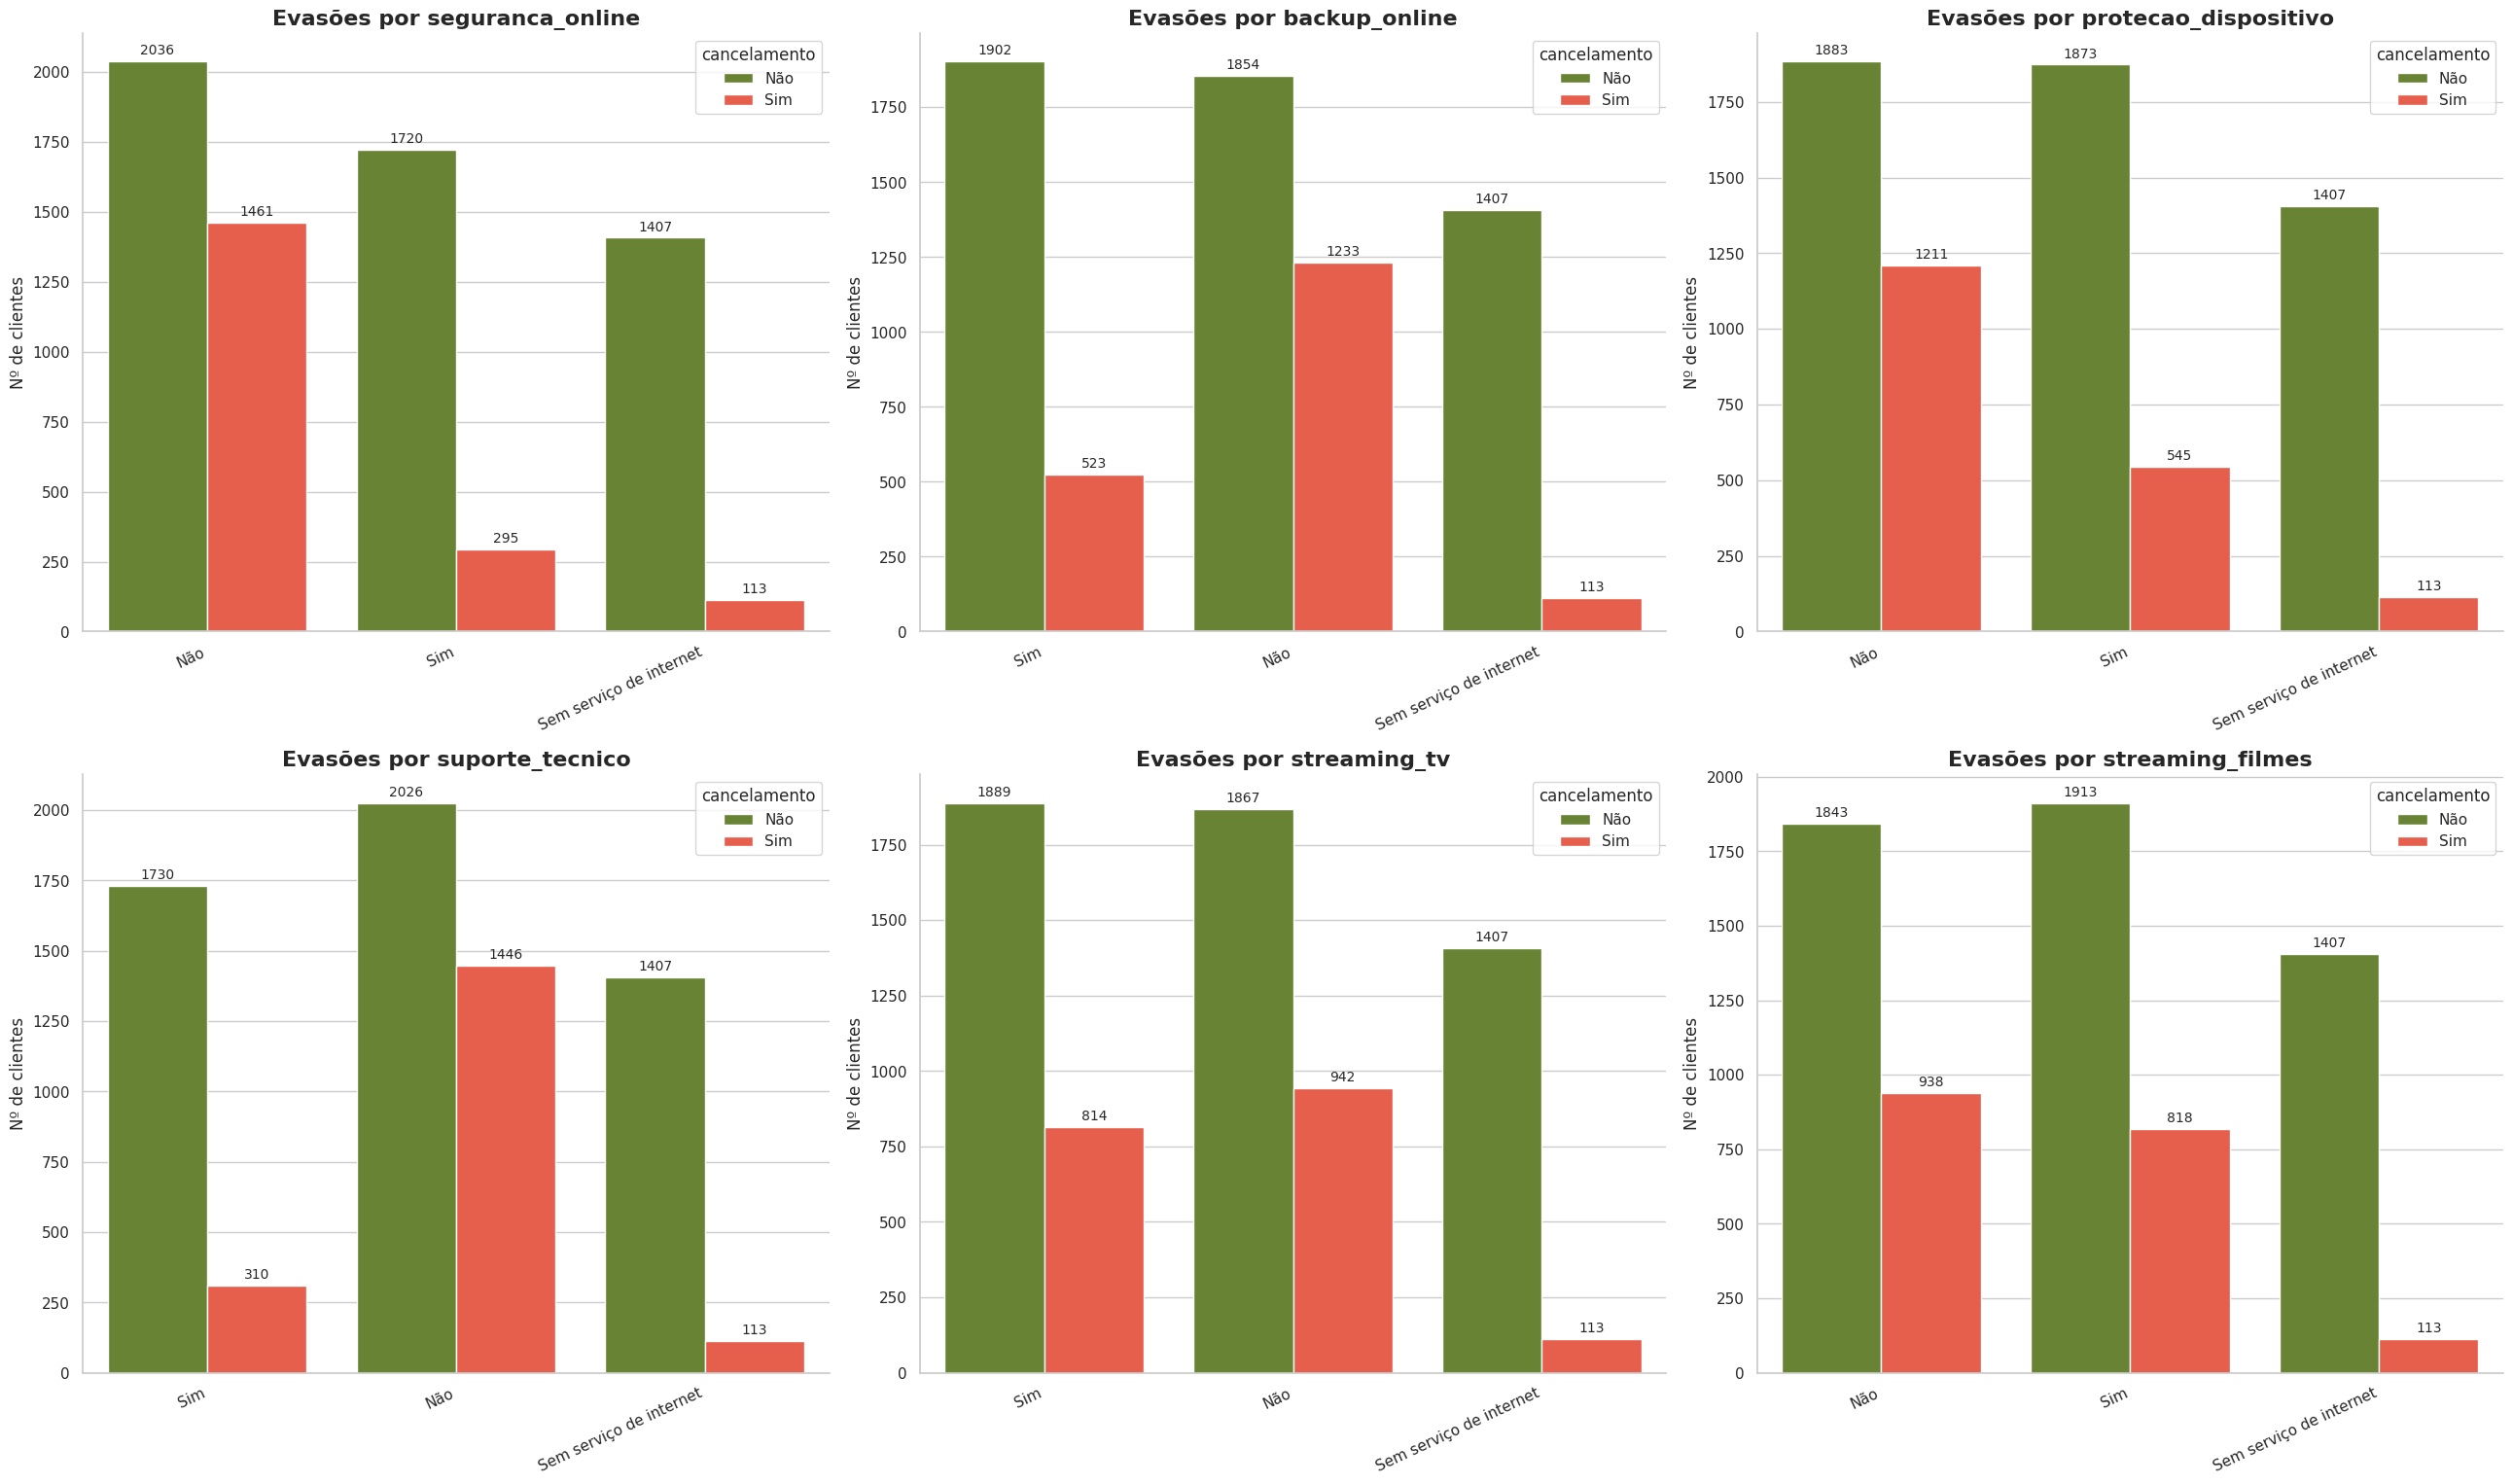

In [ ]:
variaveis_categoricas = ['seguranca_online', 'backup_online', 'protecao_dispositivo','suporte_tecnico', 'streaming_tv', 'streaming_filmes',]

lista_variaveis_categoricas = list(enumerate(variaveis_categoricas))

sns.set_theme(style="whitegrid")

plt.figure(figsize=(26, 22))

for i, var in enumerate(variaveis_categoricas):

    plt.subplot(3, 3, i + 1)

    ax = sns.countplot(data=df, x=var, hue='cancelamento', palette=['#6c9026', '#ff4b33'])

    ax.set_title(f'Evasões por {var}', fontsize=16, fontweight='bold')
    ax.set_ylabel('Nº de clientes', fontsize=12)
    ax.set_xlabel('')

    plt.xticks(rotation=25, ha='right')

    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(
                f'{int(height)}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center',
                va='bottom',
                fontsize=10,
                xytext=(0, 3),
                textcoords='offset points'
            )

    sns.despine()

plt.tight_layout()
plt.show()

###4. Evasão por variáveis numéricas

In [ ]:
import plotly.express as px

px.histogram(df, x = 'meses_de_contrato', text_auto = True, color = 'cancelamento', barmode = 'stack')

In [ ]:
px.histogram(df, x = 'total_gasto', text_auto = True, color = 'cancelamento', barmode = 'group')



---



# 📊 Relatório Final

## 📌 Introdução

A evasão de clientes, também conhecida como *Churn*, representa um dos principais desafios enfrentados por empresas que atuam com serviços por assinatura, uma vez que impactam diretamente na receita e estabilidade financeira da empresa.

Diante desse contexto, o presente relatório tem como objetivo analisar o perfil dos clientes da empresa Telecom X, buscando identificar padrões comportamentais e possíveis fatores associados ao cancelamento dos serviços. A partir dessa análise, pretende-se compreender os elementos que influenciam a evasão e gerar estratégias de retenção mais eficazes.



---



## 🧹 Limpeza e Tratamento dos Dados

Com o intuito de garantir maior consistência, organização e confiabilidade às análises, foram realizadas etapas de limpeza e tratamento dos dados.

Inicialmente, a base foi importada no formato JSON e estruturada por meio da função `pd.json_normalize()`, que permitiu transformar dados hierárquicos em um DataFrame tabular, adequado para análise exploratória.

Em seguida, foram executados os seguintes procedimentos:

- Verificação e tratamento de valores nulos;

- Ajuste dos tipos de variáveis para formatos apropriados;

- Padronização dos valores categóricos;

- Tradução e padronização dos nomes das variáveis.





---



## 🔍 Análise Exploratória de Dados

###💠 Análise Descritiva


A análise das métricas estatísticas revelou que:
- A média de tempo de contrato dos clientes, com contratos ativos e cancelados, é de **32 meses**.
- A média de tempo de contrato dos clientes que cancelaram a assinatura foi de aproximadamente **18 meses**, sendo que 25% cancelaram antes do segundo mês de contrato.
- Alta variabilidade no valor total pago, sugerindo diferenças significativas entre clientes de curto e longo prazo.

###💠 Distribuição da evasão de clientes por variáveis categóricas

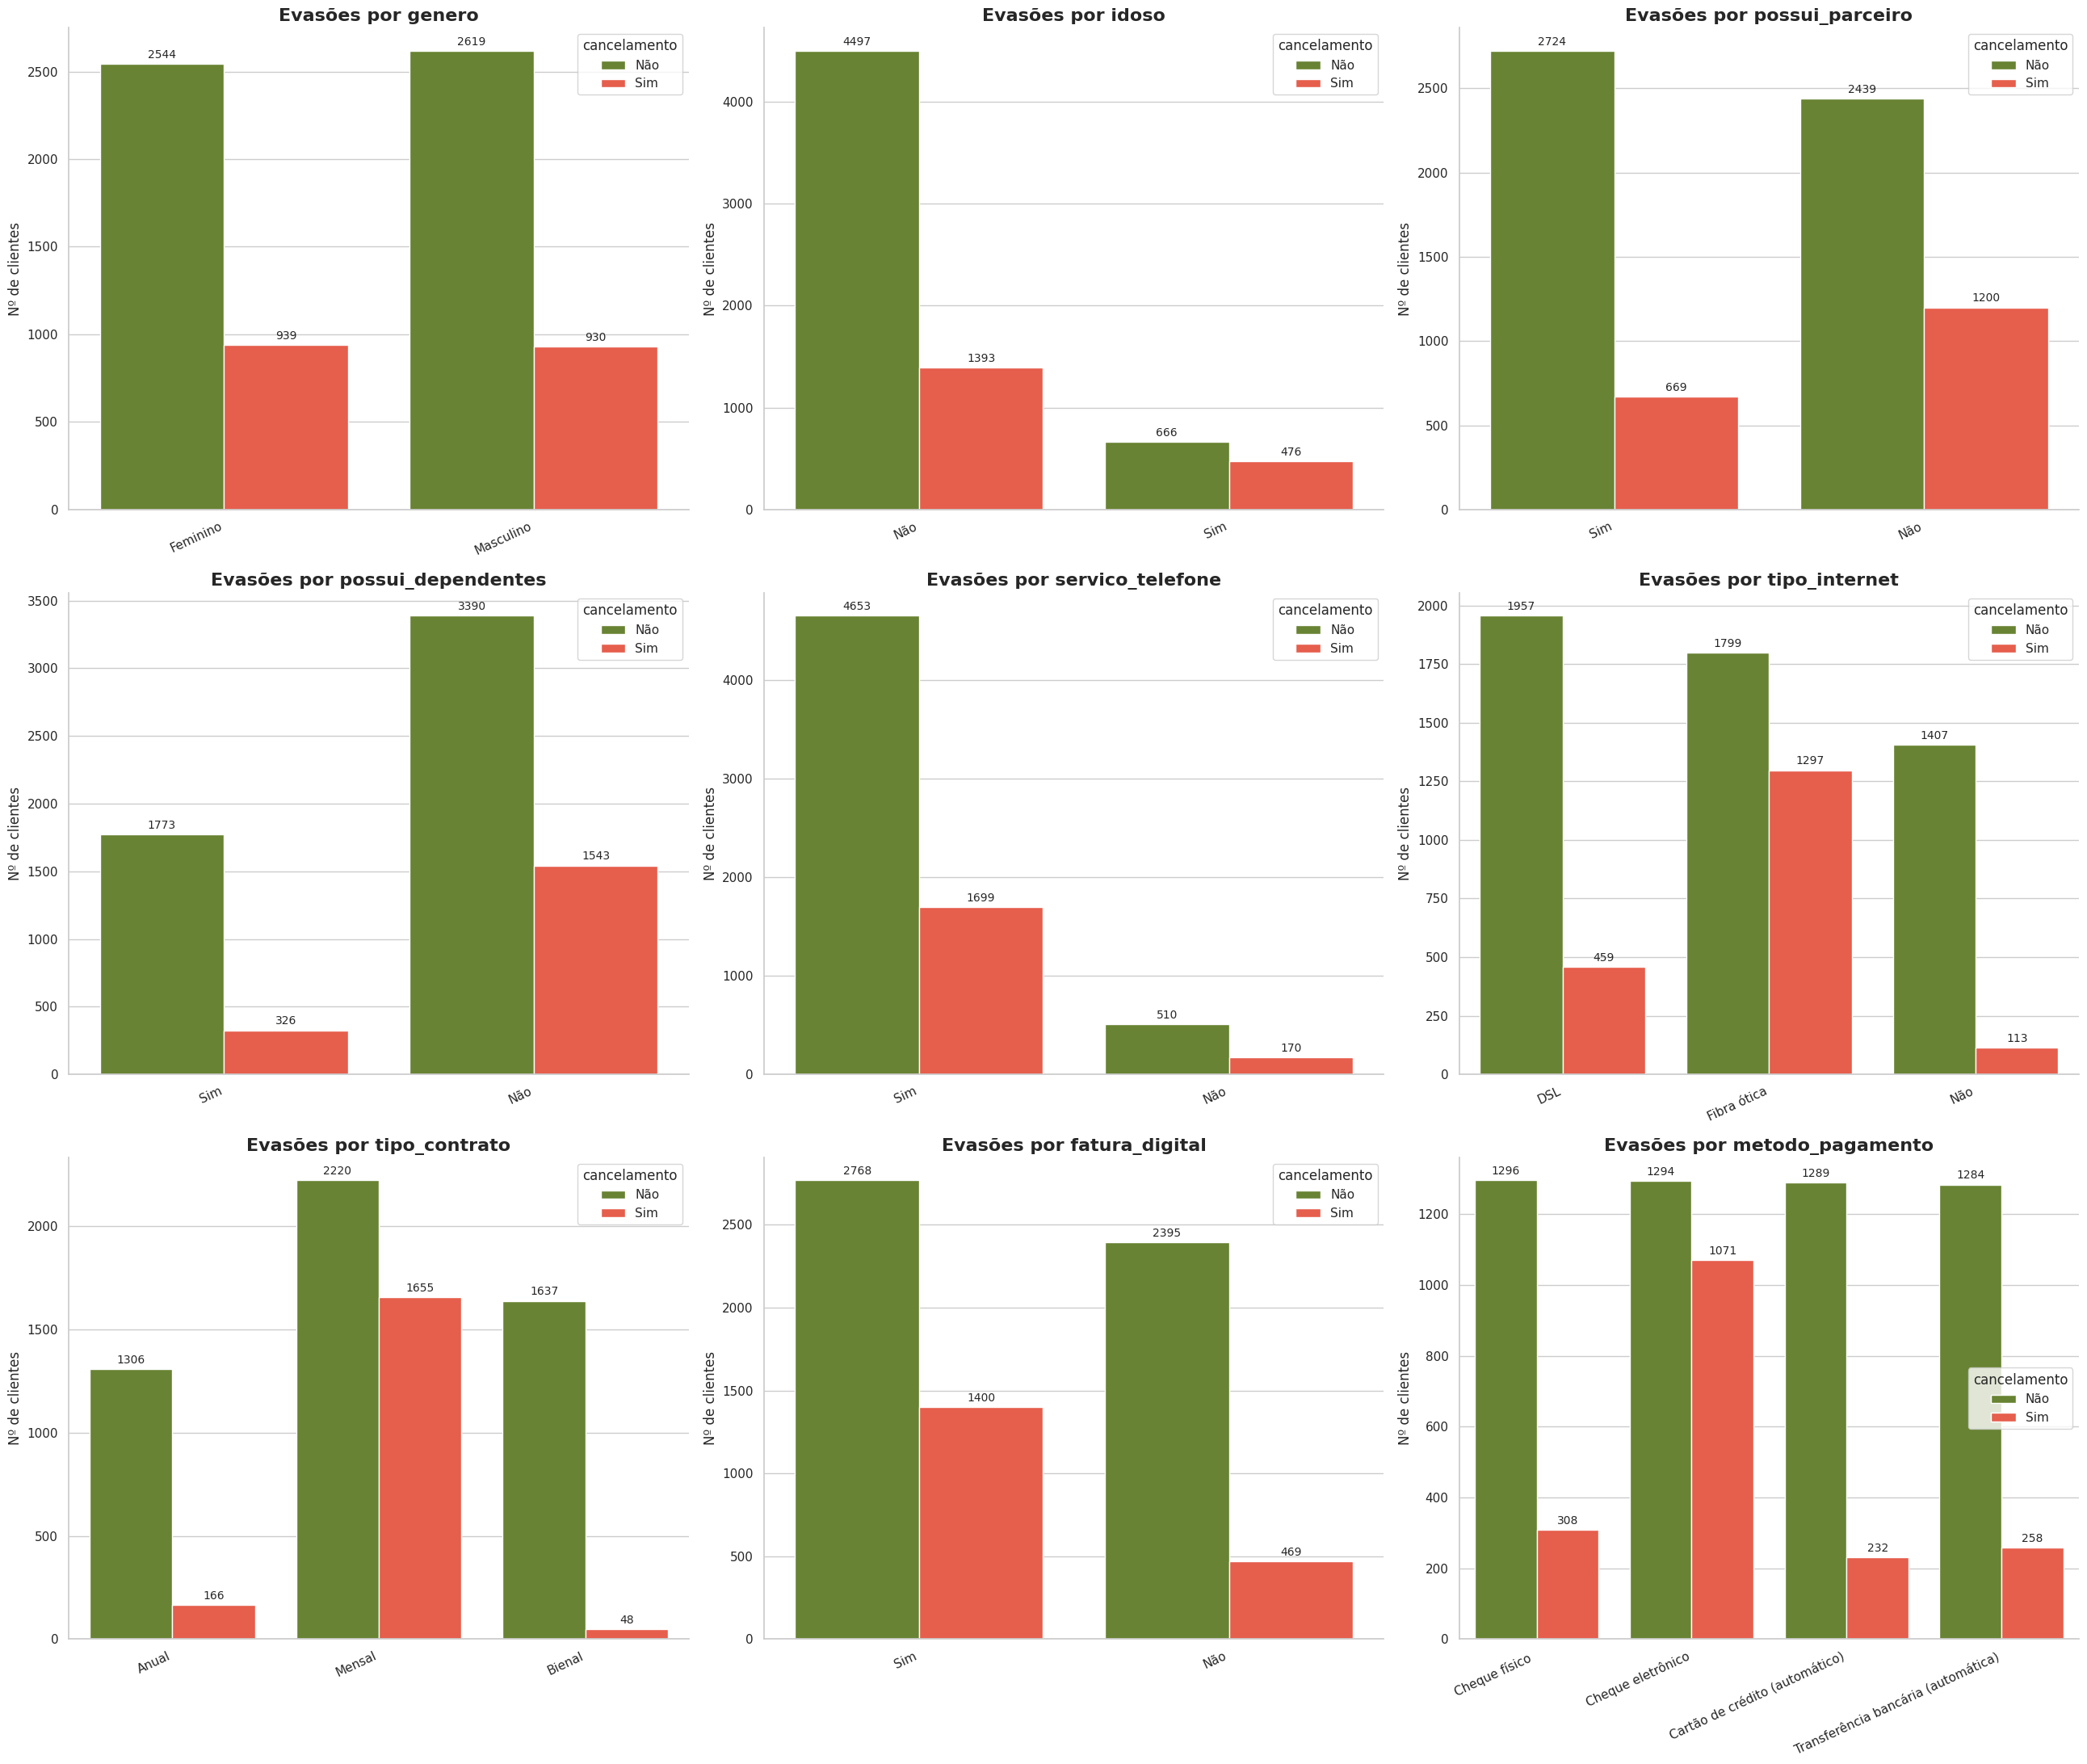

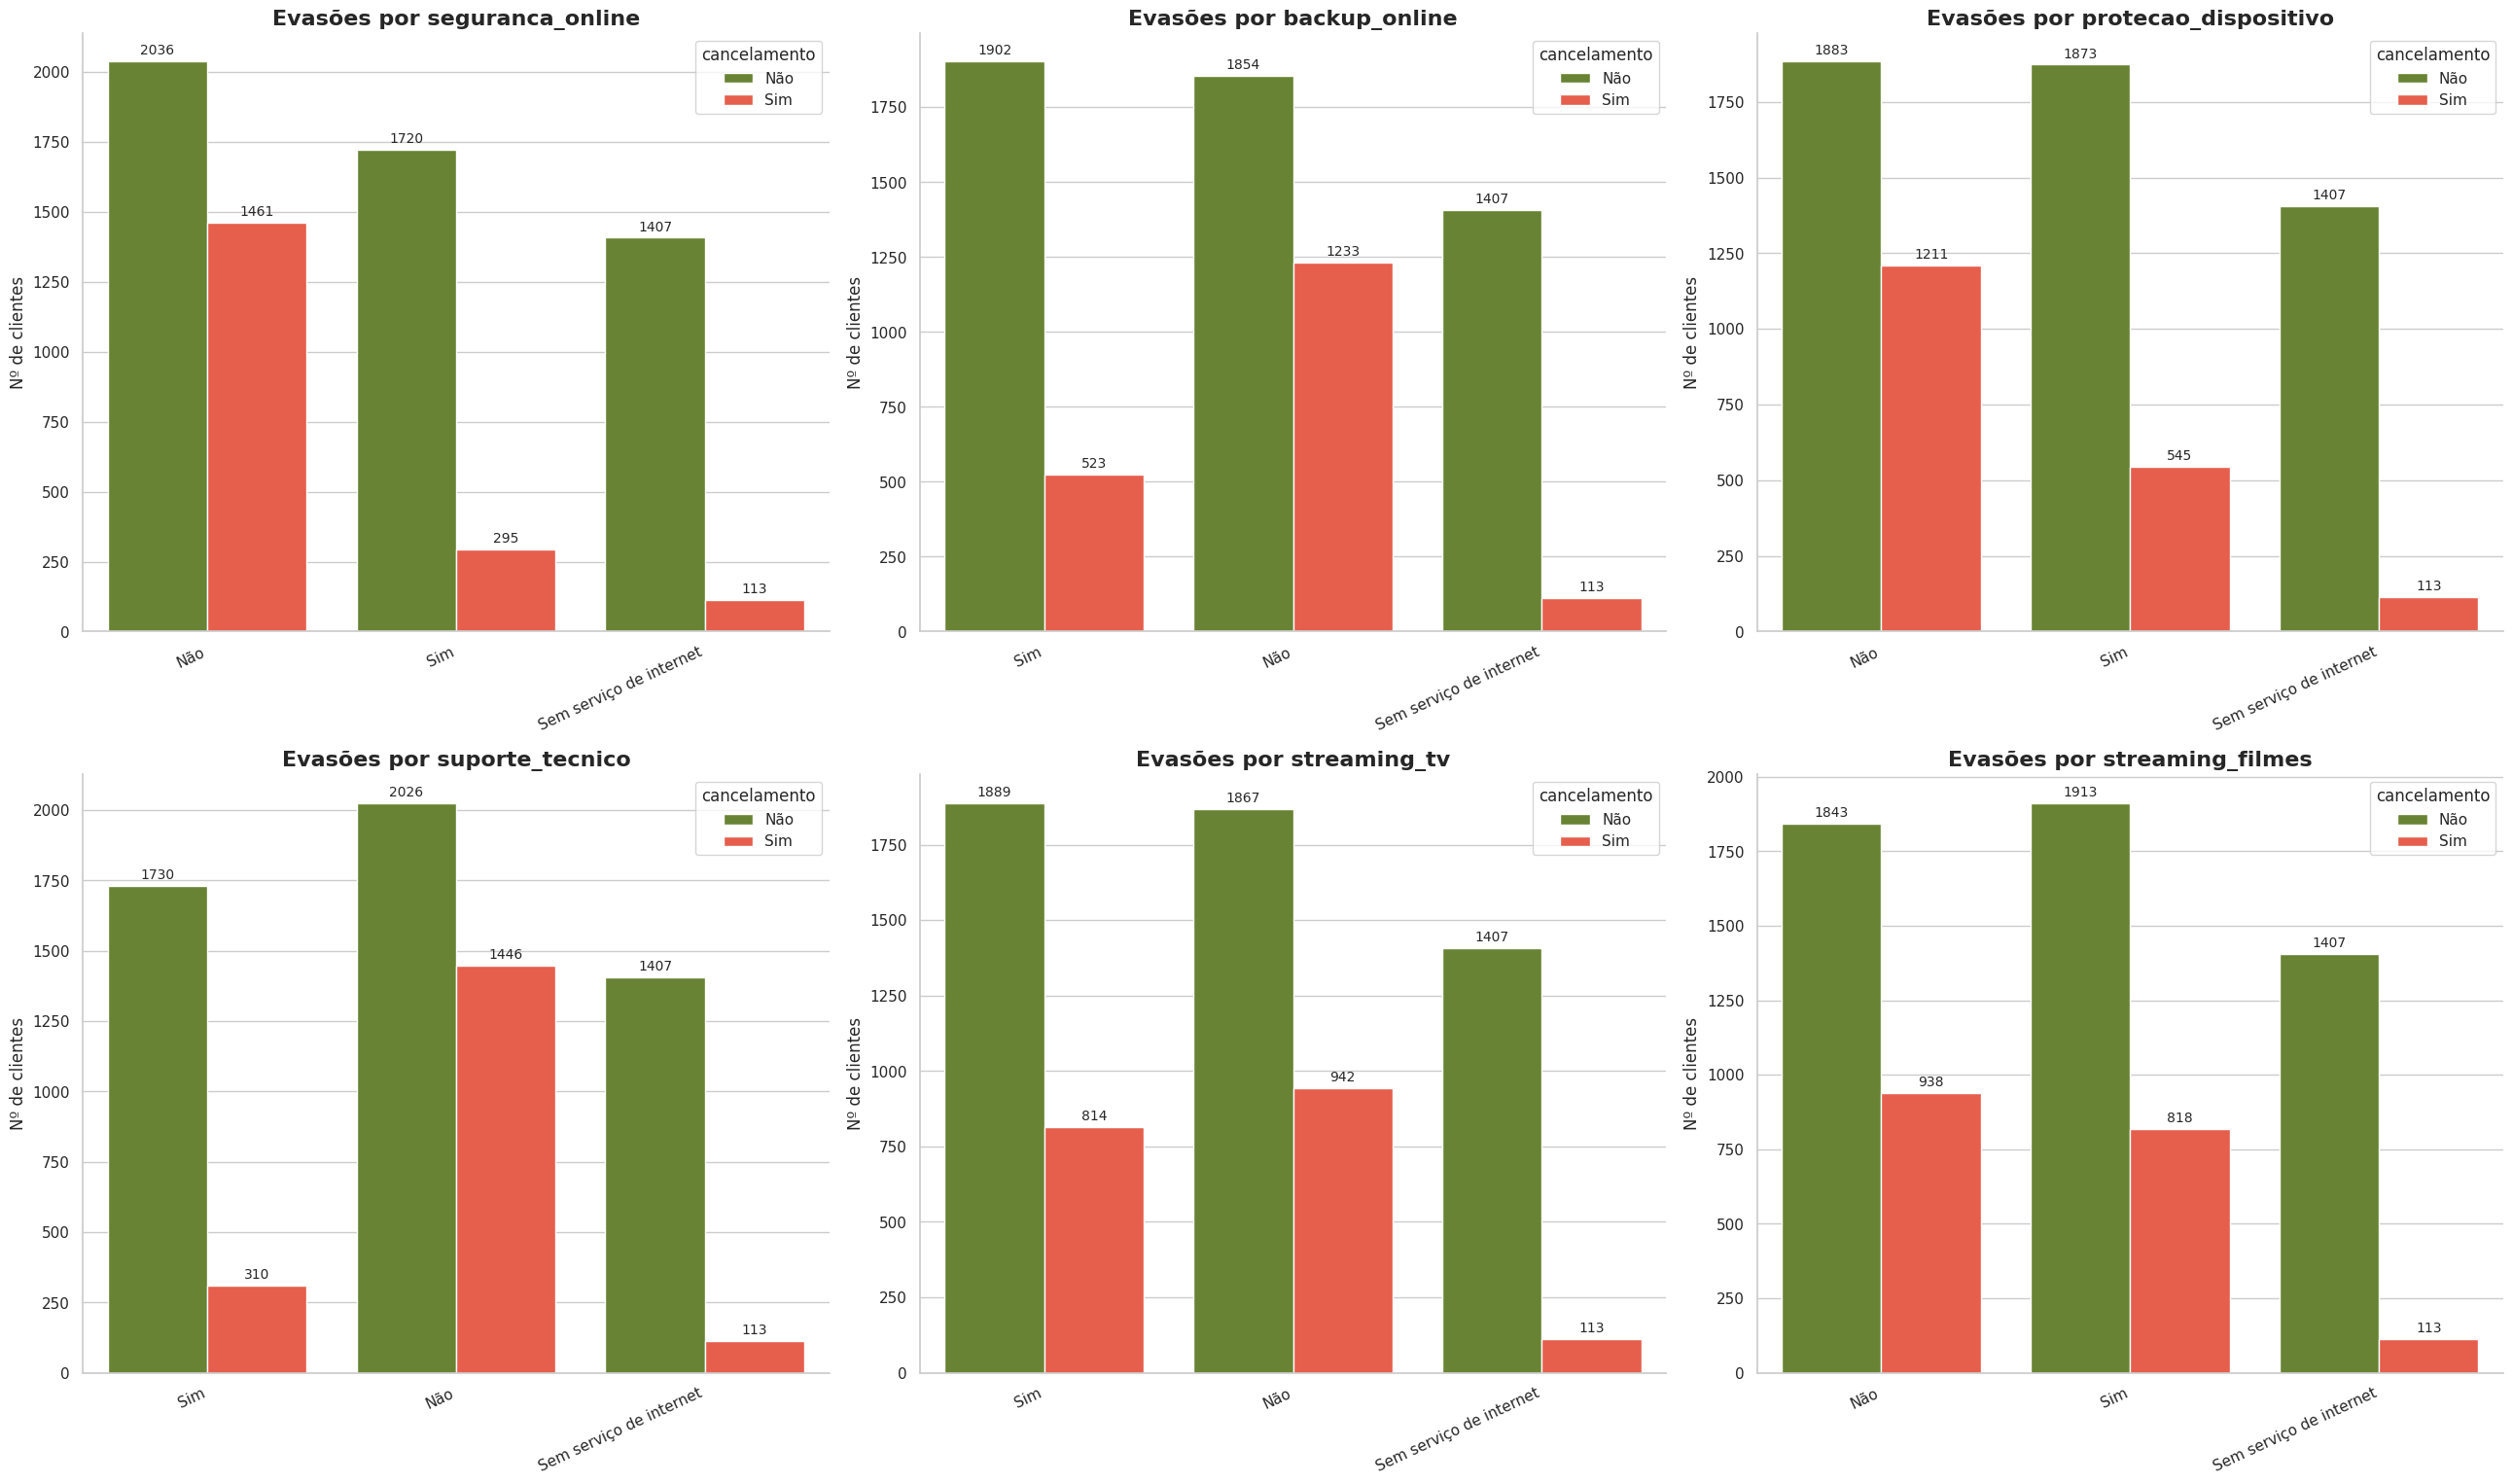

A partir da análise das variáveis categóricas, foram destacados os seguintes padrões relevantes relacionados à evasão (churn):

1. Homens e mulheres apresentam comportamento muito semelhante tanto em adesão quanto em cancelamento.

2. Em termos absolutos, clientes não idosos registram maior volume de cancelamentos, o que se justifica por representarem a maior parcela da base. No entanto, ao analisar proporcionalmente, idosos possuem taxa de cancelamento significativamente superior (41,6%) em comparação aos não idosos (23,6%), indicando maior propensão à evasão nesse grupo.

3. Clientes que utilizam fibra óptica apresentam taxa de evasão consideravelmente mais elevada quando comparados àqueles que utilizam DSL ou que não possuem serviço de internet.

4. Contratos mensais apresentam volume e taxa de cancelamento significativamente superiores (aproximadamente 42%). Em contrapartida, contratos bienais apresentam taxa de evasão extremamente reduzida (cerca de 2%).

5. Clientes que utilizam cheque eletrônico como forma de pagamento apresentam taxa de evasão mais elevada. Os demais métodos de pagamento apresentam índices semelhantes e consideravelmente menores.

6. Clientes com serviços de suporte e segurança agregados possuem menor evasão, assim como os que não possuem serviço de internet. Por outro lado, clientes que possuem internet, mas não contratam esses serviços adicionais, demonstram maior propensão ao cancelamento.

###💠 Distribuição da evasão de clientes por variáveis numéricas

**1. Meses de contrato:**

In [ ]:
import plotly.express as px

px.histogram(df, x = 'meses_de_contrato', text_auto = True, color = 'cancelamento', barmode = 'stack')

- Nos meses iniciais (principalmente entre 1 e 6 meses), o volume de cancelamentos (vermelho) é significativamente alto.
- Com o aumento do tempo de permanência, a taxa de cancelamento reduz progressivamente e tende à estabilização.
- A partir de aproximadamente 70 meses de contrato, verifica-se aumento expressivo no volume de clientes ativos, enquanto a taxa de evasão se mantém extremamente baixa, evidenciando forte fidelização nesse grupo.

**2. Total gasto:**

In [ ]:
px.histogram(df, x = 'total_gasto', text_auto = True, color = 'cancelamento', barmode = 'group')

- Os maiores volumes de cancelamento estão concentrados nas faixas mais baixas de gasto total acumulado.

- À medida que o valor total gasto aumenta, o número de cancelamentos diminui de forma acentuada.



---



##✅ Conclusão e insights

A análise exploratória permitiu identificar padrões consistentes associados à evasão de clientes (churn) na empresa Telecom X. Os resultados indicam que o cancelamento está fortemente relacionado ao tempo de contrato, tipo de plano, forma de pagamento e adesão a serviços adicionais.

### 1. O período inicial do contrato é crítico para a retenção:

Os dados evidenciam que os primeiros meses de contrato, especialmente entre 1 e 6 meses, concentram o maior volume de cancelamentos. Além disso, 25% dos clientes que cancelaram o fizeram antes do segundo mês.

💠 Isso pode indicar desalinhamento entre a expectativa criada no momento da venda e a experiência real com o serviço.

💠Ações que podem reduzir a evasão:

- Acompanhamento ativo do cliente nos primeiros meses;

- Campanhas de engajamento inicial;

- Suporte técnico acessível;

- Benefícios temporários ou testes gratuitos de serviços adicionais.
---

###2. Contratos mensais apresentam maior risco de cancelamento
Clientes com contratos mensais apresentam taxa de cancelamento significativamente superior (aproximadamente 42%), enquanto contratos de longo prazo (anual e bienal) possuem taxas bem menores (cerca de 11% e 2%, respectivamente).

💠 Isso demonstra que o nível de comprometimento contratual influencia diretamente a permanência do cliente.

💠 Ações que podem reduzir a evasão:
- incentivos financeiros para migração para planos anuais/bienais;
- descontos progressivos ou benefícios exclusivos para contratos a longo prazo.
---

###3. A agregação de serviços reduz significativamente o cancelamento
Clientes que contratam serviços adicionais, como suporte técnico, backup e segurança online, apresentam taxas de evasão consideravelmente menores. Em contrapartida, clientes que possuem serviço de internet, mas não aderem a complementos, demonstram maior propensão ao cancelamento.

💠Serviços adicionais aumentam o valor percebido e fortalecem o vínculo do cliente com a empresa.

💠 Ações que podem reduzir a evasão:
- Desconto em pacotes de serviços combinados;
- Campanhas de adesão aos serviços adicionais nos primeiros meeses de contrato.
---

###4. Usuários de cheque eletrônico apresentam maior taxa de evasão
Clientes que utilizam cheque eletrônico apresentam taxas de cancelamento mais elevadas em comparação com outros métodos de pagamento.

💠Embora a forma de pagamento não seja necessariamente a causa do cancelamento, ela pode indicar menor vínculo ou maior facilidade para interromper o serviço.

💠 Ações que podem reduzir a evasão:

- Incentivar débito automático ou cartão recorrente;
- Oferecer benefícios para métodos automatizados;